<a href="https://colab.research.google.com/github/Ayushman2005-cmyk/AML_EXPERIMENTS/blob/main/AML_LAB9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

--- Pearson Correlation Matrix ---
             X1      X2      X3  Class Y
X1       1.0000  0.9926 -0.9135   0.9649
X2       0.9926  1.0000 -0.9562   0.9258
X3      -0.9135 -0.9562  1.0000  -0.7746
Class Y  0.9649  0.9258 -0.7746   1.0000


--- CFS Merit Scores for Candidate Subsets (k = 2) ---
Feature Pair  Mean r_cf   r_ff  CFS Merit
    (X1, X2)     0.9454 0.9926     0.9471
    (X1, X3)     0.8697 0.9135     0.8892
    (X2, X3)     0.8502 0.9562     0.8597




/tmp/ipykernel_1945/2896323904.py:58: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  bars = sns.barplot(data=cfs_df, x='Feature Pair', y='CFS Merit', palette=palette, ax=axes[1])


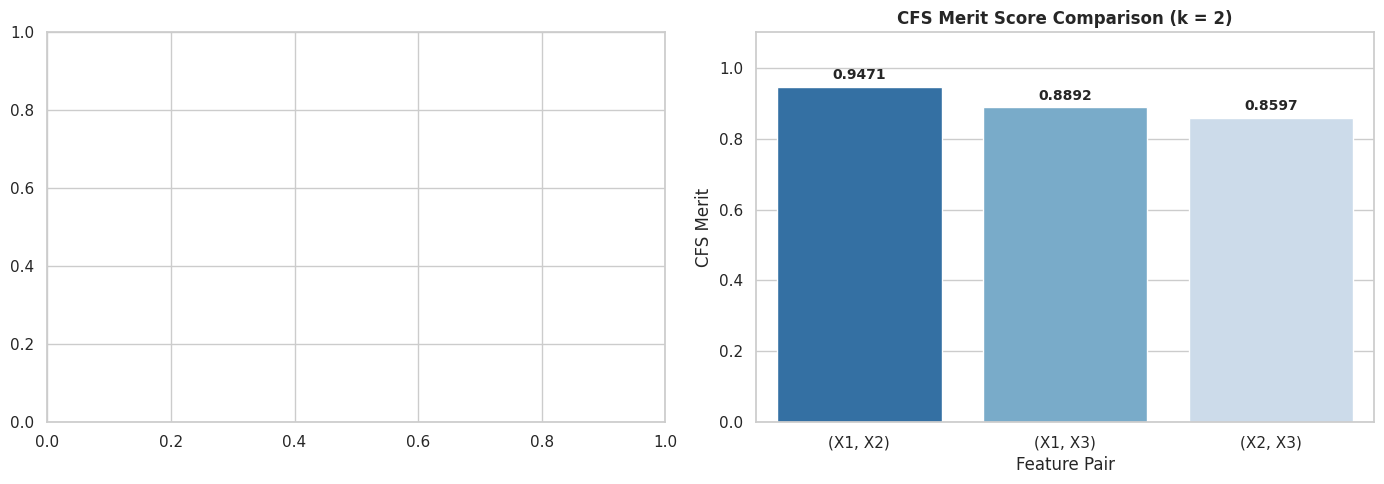

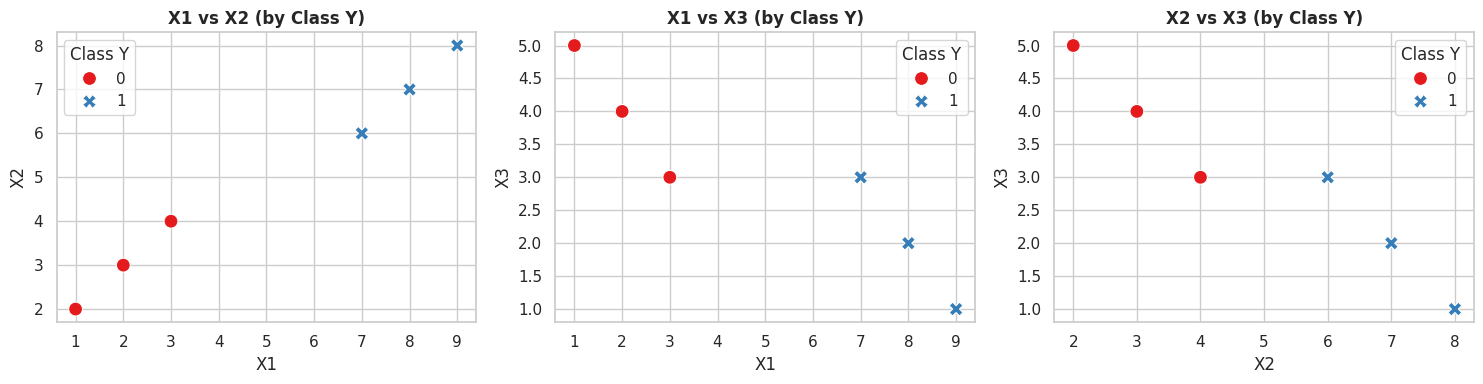

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from itertools import combinations

sns.set_theme(style="whitegrid")

data = {
    'Student': [1, 2, 3, 4, 5, 6],
    'X1': [1, 2, 3, 7, 8, 9],
    'X2': [2, 3, 4, 6, 7, 8],
    'X3': [5, 4, 3, 3, 2, 1],
    'Class Y': [0, 0, 0, 1, 1, 1]
}

df = pd.DataFrame(data)
features = ['X1', 'X2', 'X3']
target = 'Class Y'

corr_matrix = df[features + [target]].corr(method='pearson')

print("--- Pearson Correlation Matrix ---")
print(corr_matrix.round(4))
print("\n" + "="*50 + "\n")

k = 2
subsets_k2 = list(combinations(features, k))

cfs_results = []
for subset in subsets_k2:
    f1, f2 = subset

    r_cf1 = abs(corr_matrix.loc[f1, target])
    r_cf2 = abs(corr_matrix.loc[f2, target])
    r_cf_mean = (r_cf1 + r_cf2) / k

    r_ff_mean = abs(corr_matrix.loc[f1, f2])

    merit = (k * r_cf_mean) / np.sqrt(k + k * (k - 1) * r_ff_mean)

    cfs_results.append({
        'Feature Pair': f"({f1}, {f2})",
        'Mean r_cf': round(r_cf_mean, 4),
        'r_ff': round(r_ff_mean, 4),
        'CFS Merit': round(merit, 4)
    })

cfs_df = pd.DataFrame(cfs_results).sort_values(by='CFS Merit', ascending=False)

print("--- CFS Merit Scores for Candidate Subsets (k = 2) ---")
print(cfs_df.to_string(index=False))
print("\n" + "="*50 + "\n")

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

palette = sns.color_palette("Blues_r", len(cfs_df))
bars = sns.barplot(data=cfs_df, x='Feature Pair', y='CFS Merit', palette=palette, ax=axes[1])
axes[1].set_title('CFS Merit Score Comparison (k = 2)', fontsize=12, fontweight='bold')
axes[1].set_ylim(0, 1.1)

for bar in bars.patches:
    bars.annotate(f"{bar.get_height():.4f}",
                  (bar.get_x() + bar.get_width() / 2., bar.get_height()),
                  ha='center', va='bottom', fontsize=10, fontweight='bold',
                  xytext=(0, 3), textcoords='offset points')

plt.tight_layout()
plt.show()

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

pair_list = list(subsets_k2)
for idx, (f1, f2) in enumerate(pair_list):
    sns.scatterplot(data=df, x=f1, y=f2, hue=target, style=target,
                    s=100, palette='Set1', ax=axes[idx])
    axes[idx].set_title(f'{f1} vs {f2} (by {target})', fontweight='bold')

plt.tight_layout()
plt.show()